In [86]:
import os
import pydicom
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input, MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from keras.losses import Huber

In [87]:
# configs
IMG_SIZE = 224
BATCH_SIZE = 64
DATA_DIR = 'rsna-pneumonia-detection-challenge/'
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'stage_2_train_images')
TRAIN_LABELS_PATH = os.path.join(DATA_DIR, 'stage_2_train_labels.csv')

In [88]:
def load_dicom_image(path):
    """Return grayscale DICOM as float32 0..1, stacked to 3 channels."""
    try:
        dicom = pydicom.dcmread(path)
        img = dicom.pixel_array.astype(np.float32)

        if img.max() > 0:
            img = img / img.max()  # scale to 0..1 using actual max
        else:
            img = img  # edge case (all-zero image)

        img = np.stack([img, img, img], axis=-1)  # (H, W, 3)
        return img
    except Exception as e:
        print(f"[Warning] failed to load DICOM {path}: {e}")
        return None

In [89]:
def preprocess_data(df_labels, img_dir, target_size, max_samples=None):
    """
    Returns:
      X_raw   : numpy array of shape (N, target_size, target_size, 3), dtype=uint8 (0..255) for display
      X_model : numpy array of shape (N, target_size, target_size, 3), dtype=float32 preprocessed for MobileNetV2
      Y       : numpy array of shape (N, 4) normalized [cx, cy, w, h]
    """
    df_pos = df_labels[df_labels["Target"] == 1].copy()

    if max_samples is not None:
        df_pos = df_pos.iloc[:max_samples]

    X_raw_list = []
    X_model_list = []
    Y_list = []

    for idx, row in df_pos.iterrows():
        pid = row["patientId"]
        img_path = os.path.join(img_dir, f"{pid}.dcm")

        if not os.path.exists(img_path):
            print(f"[Warning] missing file: {img_path}")
            continue

        img_orig = load_dicom_image(img_path)
        if img_orig is None:
            continue

        H, W = img_orig.shape[:2]

        # Resize (keep raw in 0..1)
        img_resized_raw = tf.image.resize(img_orig, (target_size, target_size)).numpy()  # still float32 0..1

        # Produce display image (0..255 uint8)
        img_display = (img_resized_raw * 255.0).astype(np.uint8)

        # Produce model input -- MobileNetV2 expects input range 0..255 before preprocess_input
        img_for_model = preprocess_input(img_resized_raw * 255.0)  # float32 in [-1, +1]

        # bbox normalization
        x_min = row["x"]
        y_min = row["y"]
        width = row["width"]
        height = row["height"]
        norm_x_min = x_min / W
        norm_y_min = y_min / H
        norm_width = width / W
        norm_height = height / H

        x_center = norm_x_min + norm_width / 2.0
        y_center = norm_y_min + norm_height / 2.0

        bbox = [x_center, y_center, norm_width, norm_height]

        X_raw_list.append(img_display)
        X_model_list.append(img_for_model)
        Y_list.append(bbox)

    X_raw = np.array(X_raw_list) if len(X_raw_list) > 0 else np.empty((0, target_size, target_size, 3), dtype=np.uint8)
    X_model = np.array(X_model_list, dtype=np.float32) if len(X_model_list) > 0 else np.empty((0, target_size, target_size, 3), dtype=np.float32)
    Y = np.array(Y_list, dtype=np.float32) if len(Y_list) > 0 else np.empty((0, 4), dtype=np.float32)

    return X_raw, X_model, Y

In [90]:
def build_localization_model(input_shape, freeze_base=True):

    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
        name="mobilenet_base"
    )

    if freeze_base:
        for layer in base_model.layers:
            layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(1024, activation='relu')(x)
    x = Dense(512, activation='relu')(x)

    bbox_output = Dense(4, activation='sigmoid', name='bbox_output')(x)

    model = Model(inputs=base_model.input, outputs=bbox_output)
    model.compile(
                  optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5),
                  loss=Huber(delta=1.0),
                  metrics=[tf.keras.losses.Huber(delta=1.0)])
    return model

In [91]:
def denormalize_bbox(bbox, img_size):
    """bbox = [cx, cy, w, h] normalized → return pixel bbox (x1,y1,x2,y2) on img_size square."""
    cx, cy, w, h = bbox
    cx *= img_size
    cy *= img_size
    w *= img_size
    h *= img_size
    x1 = int(round(cx - w / 2.0))
    y1 = int(round(cy - h / 2.0))
    x2 = int(round(cx + w / 2.0))
    y2 = int(round(cy + h / 2.0))
    return x1, y1, x2, y2

In [92]:
def compute_iou(gt, pred):
    gx1, gy1, gx2, gy2 = gt
    px1, py1, px2, py2 = pred
    inter_x1 = max(gx1, px1)
    inter_y1 = max(gy1, py1)
    inter_x2 = min(gx2, px2)
    inter_y2 = min(gy2, py2)
    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h
    gt_area = max(0, (gx2 - gx1)) * max(0, (gy2 - gy1))
    pred_area = max(0, (px2 - px1)) * max(0, (py2 - py1))
    union = gt_area + pred_area - inter_area
    return (inter_area / union) if union > 0 else 0.0

In [93]:
def show_prediction(img_display_uint8, gt_bbox_px, pred_bbox_px, title=""):
    """
    img_display_uint8: HxWx3 uint8 image (0..255) for display
    gt_bbox_px / pred_bbox_px: (x1,y1,x2,y2) in pixels
    """
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    ax.imshow(img_display_uint8)
    # GT green
    gx1, gy1, gx2, gy2 = gt_bbox_px
    rect_gt = patches.Rectangle((gx1, gy1), gx2 - gx1, gy2 - gy1,
                                linewidth=2, edgecolor="lime", facecolor="none", label="GT")
    ax.add_patch(rect_gt)
    # Pred red
    px1, py1, px2, py2 = pred_bbox_px
    rect_pred = patches.Rectangle((px1, py1), px2 - px1, py2 - py1,
                                  linewidth=2, edgecolor="red", facecolor="none", label="Pred")
    ax.add_patch(rect_pred)
    ax.legend(loc="upper right")
    ax.set_axis_off()
    ax.set_title(title)
    plt.show()

In [94]:
def visualize_predictions(model, X_raw, X_model, Y, N=5, img_size=IMG_SIZE):
    """
    model: trained Keras model (predicts normalized [cx,cy,w,h])
    X_raw: uint8 images for display (N_total, img_size, img_size, 3)
    X_model: model inputs (N_total, img_size, img_size, 3)
    Y: GT normalized bboxes (N_total, 4)
    """
    preds = model.predict(X_model, batch_size=32)
    samples = []

    for i in range(len(X_model)):
        gt_px = denormalize_bbox(Y[i], img_size)
        pred_px = denormalize_bbox(preds[i], img_size)
        iou = compute_iou(gt_px, pred_px)
        samples.append((i, iou, gt_px, pred_px))

    samples.sort(key=lambda s: s[1], reverse=True)

    print(f"Showing {N} best predictions:")
    for idx, iou, gt_px, pred_px in samples[:N]:
        show_prediction(X_raw[idx], gt_px, pred_px, title=f"IOU={iou:.3f}")

    print(f"Showing {N} worst predictions:")
    for idx, iou, gt_px, pred_px in samples[-N:]:
        show_prediction(X_raw[idx], gt_px, pred_px, title=f"IOU={iou:.3f}")

In [95]:
df_labels = pd.read_csv(TRAIN_LABELS_PATH)

# Load N samples (only positive rows). Use max_samples to limit.
X_raw, X_model, Y = preprocess_data(df_labels, TRAIN_IMG_DIR, IMG_SIZE, max_samples=4000)

In [96]:
# Train/test split: use indices to keep correspondence between raw and model inputs
idxs = np.arange(len(X_model))
train_idx, test_idx = train_test_split(idxs, test_size=0.2, random_state=69)

X_model_train, X_model_test = X_model[train_idx], X_model[test_idx]
Y_train, Y_test = Y[train_idx], Y[test_idx]
X_raw_train, X_raw_test = X_raw[train_idx], X_raw[test_idx]

In [97]:
# Build and train
model = build_localization_model((IMG_SIZE, IMG_SIZE, 3), freeze_base=True)
history = model.fit(X_model_train, Y_train, validation_data=(X_model_test, Y_test),
                    epochs=5, batch_size=BATCH_SIZE)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 26s 478ms/step - huber_loss: 0.0135 - loss: 0.0135 - val_huber_loss: 0.0096 - val_loss: 0.0096
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 452ms/step - huber_loss: 0.0091 - loss: 0.0091 - val_huber_loss: 0.0095 - val_loss: 0.0095
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 450ms/step - huber_loss: 0.0085 - loss: 0.0085 - val_huber_loss: 0.0095 - val_loss: 0.0095
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 450ms/step - huber_loss: 0.0079 - loss: 0.0079 - val_huber_loss: 0.0095 - val_loss: 0.0095
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 23s 451ms/step - huber_loss: 0.0075 - loss: 0.0075 - val_huber_loss: 0.0096 - val_loss: 0.0096


25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step
Showing 5 best predictions:


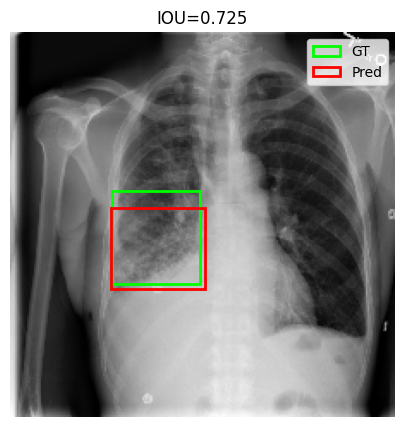

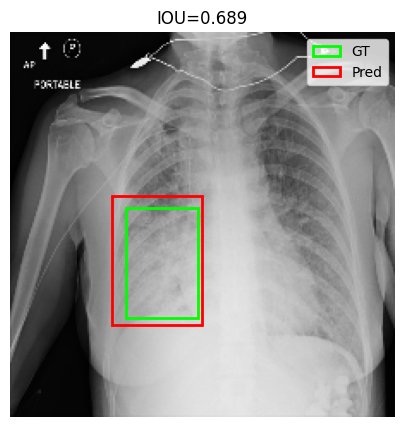

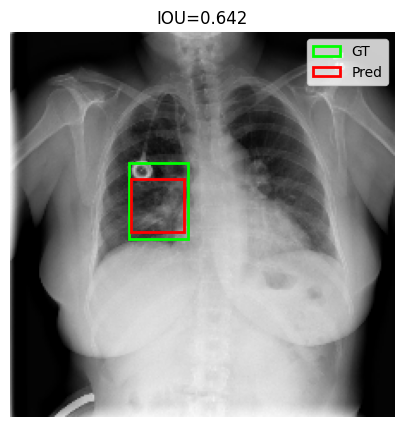

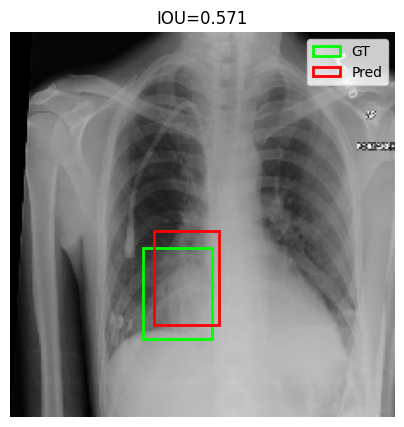

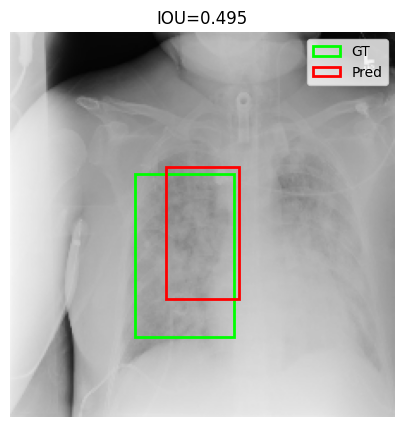

Showing 5 worst predictions:


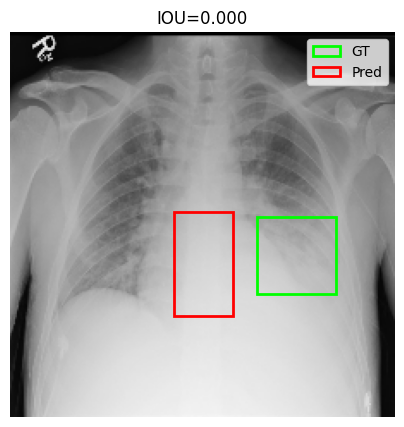

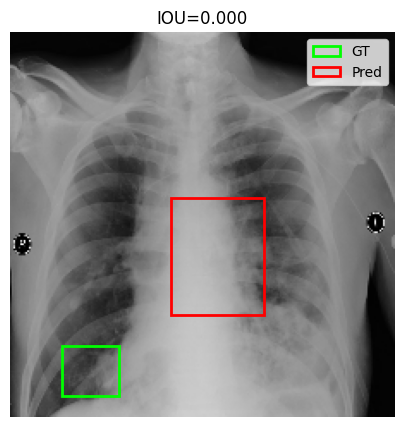

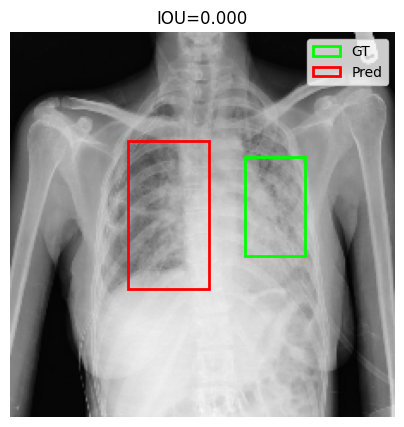

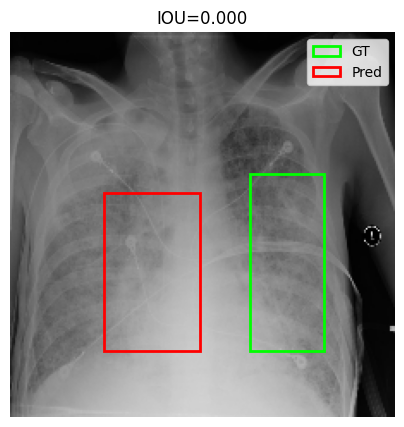

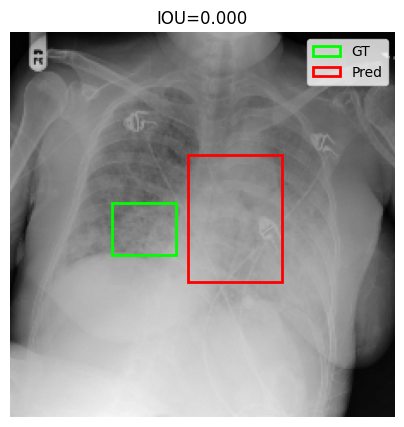

In [98]:
visualize_predictions(model, X_raw_test, X_model_test, Y_test, N=5, img_size=IMG_SIZE)

In [100]:
def unfreeze_top_layers(model, percent=0.35):
    """
    Unfreeze the top `percent` of MobileNetV2 layers.
    Automatically identifies backbone layers by name.
    """

    # Identify MobileNetV2 layers (the backbone)
    backbone_prefixes = ("Conv", "expanded_conv", "block_", "out_relu")
    backbone_layers = [l for l in model.layers if l.name.startswith(backbone_prefixes)]

    total = len(backbone_layers)
    unfreeze_from = int(total * (1 - percent))

    print(f"Detected {total} MobileNetV2 layers.")
    print(f"Unfreezing from layer index {unfreeze_from} → {total-1}")

    # Freeze entire backbone first
    for layer in backbone_layers:
        layer.trainable = False

    # Unfreeze last percent
    for layer in backbone_layers[unfreeze_from:]:
        layer.trainable = True

    return model


In [101]:
model_frozen = build_localization_model((IMG_SIZE, IMG_SIZE, 3), freeze_base=True)

# Train the localization head (base frozen)
history_frozen = model_frozen.fit(
    X_model_train, Y_train,
    validation_data=(X_model_test, Y_test),
    epochs=10,
    batch_size=BATCH_SIZE
)

# Save before fine-tuning
model_frozen.save("model_before_finetune.keras")
print("Saved model_before_finetune")

# Now fine-tune
model_ft = unfreeze_top_layers(model_frozen, percent=0.8)

model_ft.compile(
    optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5),
    loss=Huber(delta=1.0),
    metrics=[tf.keras.losses.Huber(delta=1.0)]
)

history_fine = model_ft.fit(
    X_model_train, Y_train,
    validation_data=(X_model_test, Y_test),
    epochs=15,
    batch_size=BATCH_SIZE
)

model_ft.save("model_after_finetune.keras")
print("Saved model_after_finetune")

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 29s 539ms/step - huber_loss: 0.0128 - loss: 0.0128 - val_huber_loss: 0.0101 - val_loss: 0.0101
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 498ms/step - huber_loss: 0.0090 - loss: 0.0090 - val_huber_loss: 0.0098 - val_loss: 0.0098
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 493ms/step - huber_loss: 0.0083 - loss: 0.0083 - val_huber_loss: 0.0097 - val_loss: 0.0097
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 491ms/step - huber_loss: 0.0077 - loss: 0.0077 - val_huber_loss: 0.0099 - val_loss: 0.0099
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 490ms/step - huber_loss: 0.0073 - loss: 0.0073 - val_huber_loss: 0.0098 - val_loss: 0.0099
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 490ms/step - huber_loss: 0.0068 - loss: 0.0068 - val_huber_loss: 0.0100 - val_loss: 0.0100
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 490ms/step - huber_loss: 0.0065 - loss: 0.0065 - val_huber_loss: 0.0103 - val_loss: 0.0103
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 25s 492ms/step - huber_loss: 0.

25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 173ms/step
Showing 3 best predictions:


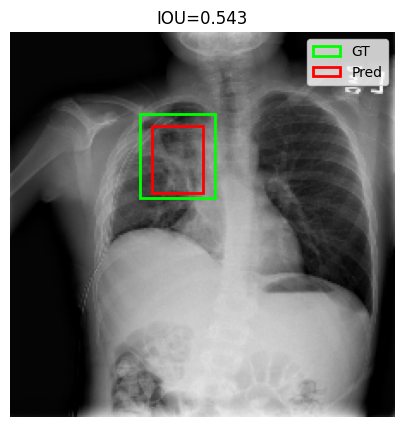

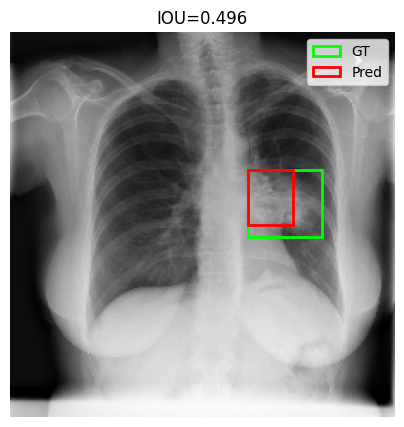

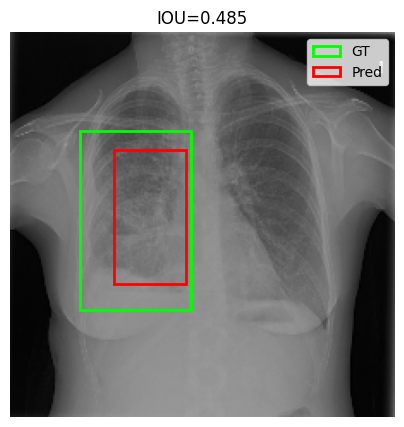

Showing 3 worst predictions:


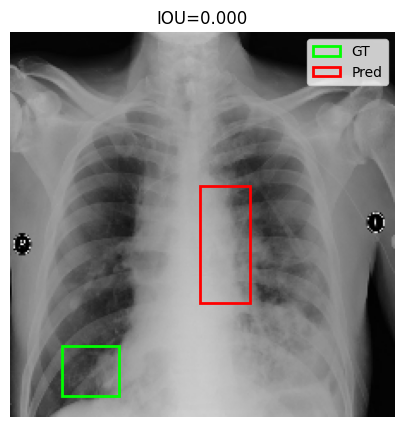

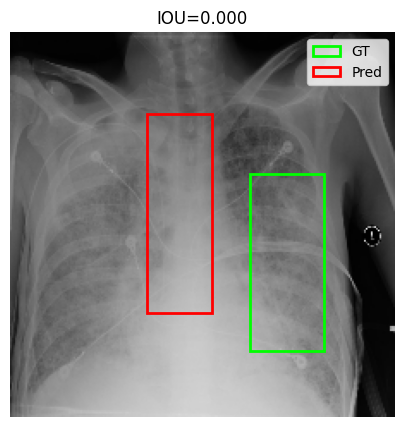

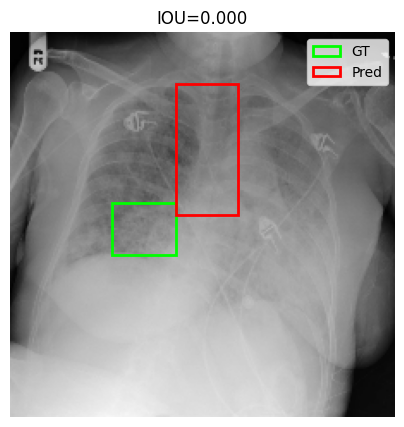

In [102]:
visualize_predictions(model_ft, X_raw_test, X_model_test, Y_test, N=3, img_size=IMG_SIZE)